In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from brian2 import StateMonitor, ms
from skfem import Basis, BilinearForm, ElementTriP1, LinearForm, MeshTri, asm
from skfem.helpers import dot, grad

from sango import EdgeGroup, Network, NodeGroup
from sango.backend import SimBrian
from sango.model import Neuron, Synapse

# NeuroFEM Using Scikit-FEM

This code aims to reproduce work performed in:

```bibtex
@article{theilman2025solving,
  title={Solving sparse finite element problems on neuromorphic hardware},
  author={Theilman, Bradley H and Aimone, James B},
  journal={Nature Machine Intelligence},
  volume={7},
  number={11},
  pages={1845--1857},
  year={2025},
  publisher={Nature Publishing Group UK London}
}
```

specifically the steady-state Poisson equation on a disk with Dirichlet boundary conditions.

This notebook aims to simplify much of the FEM system creation by using `scikit-fem` to produce the matrices needed for the system to be implemented as an SNN and run using Sango with its Brian2 backend.

# Parameters

In [2]:
NEURONS_PER_MESH_POINT = 8
GAMMA_NORM = 2**-6
LAMBDA_D = 8.0
LAMBDA_V = 16.0
KP = 4.0
KI = 16.0
SIGMA_V = 0.00225
SIMULATION_TIME = 50_000
DT = 2**-12 * ms

# Build Mesh System

## Define the System

In [3]:
@BilinearForm
def laplace(u, v, w):
    return dot(grad(u), grad(v))


@LinearForm
def rhs_constant(v, w):
    # We solve -Delta u = 20
    return 20.0 * v

## Build the Mesh in scikit-fem

In [4]:
def build_poisson_disk_system(nrefs: int = 4) -> tuple:
    """
    Build the FEM system for:

        -Delta u = 20 on unit disk
            u = 0 on boundary

    Returns the reduced interior system A x = b.

    :param nrefs: Number of refinements for constructing the mesh, defaults to 4
    :type nrefs: int, optional
    :return: tuple containing the components of the FEM system where:
        - mesh - The mesh object
        - basis - Finite-element basis on the mesh
        - interior - non-boundary nodes in the mesh
        - A - stiffness matrix for the interior nodes
        - b - right-hand side (i.e. load) vector
        - xy - coordinates for the interior nodes
    :rtype: tuple
    """

    # Unit disk triangular mesh
    mesh = MeshTri.init_circle(nrefs=nrefs)

    # P1 finite elements: one scalar DOF per vertex
    element = ElementTriP1()
    basis = Basis(mesh, element)

    # Full stiffness matrix and RHS
    A_full = asm(laplace, basis).tocsr()
    b_full = asm(rhs_constant, basis)

    # Boundary and interior DOFs
    boundary = mesh.boundary_nodes()
    all_nodes = np.arange(mesh.p.shape[1])
    interior = np.setdiff1d(all_nodes, boundary)

    # Homogeneous Dirichlet condition u=0 means we solve only interior block
    A = A_full[interior][:, interior].tocsr()
    b = b_full[interior]

    # Coordinates of interior nodes
    xy = mesh.p[:, interior].T

    return mesh, basis, interior, A, b, xy


## Construct Gamma Matrix

In [5]:
def build_gamma(
    n_mesh: int, neurons_per_mesh_point: int = 8, gamma_norm: float = 2**-6
) -> sp.spmatrix:
    """
    Build sparse Gamma matrix of shape:

        n_mesh x n_neurons

    where n_neurons = n_mesh * neurons_per_mesh_point.

    :param n_mesh: number of mesh points
    :type n_mesh: int
    :param neurons_per_mesh_point: number of neurons per mesh point,
        defaults to 8
    :type neurons_per_mesh_point: int, optional
    :param gamma_norm: magnitude of the readout weight, defaults to 2**-6
    :type gamma_norm: float, optional
    :return: Sparse readout matrix with shape
        (n_mesh, n_mesh * neurons_per_mesh_point).
    :rtype: sp.spmatrix
    """

    # Check that there is an even number of neurons per mesh point
    assert neurons_per_mesh_point % 2 == 0

    # Compute total number of neurons in the mesh
    n_neurons = n_mesh * neurons_per_mesh_point

    # Half of the neurons will be excitatory and half inhibitory
    half = neurons_per_mesh_point // 2

    rows = []
    cols = []
    data = []

    # Construct the Gamma matrix in a sparse way
    for i in range(n_mesh):
        start = i * neurons_per_mesh_point

        # Negative readout neurons
        for k in range(half):
            rows.append(i)
            cols.append(start + k)
            data.append(-gamma_norm)

        # Positive readout neurons
        for k in range(half, neurons_per_mesh_point):
            rows.append(i)
            cols.append(start + k)
            data.append(gamma_norm)

    Gamma = sp.csr_matrix((data, (rows, cols)), shape=(n_mesh, n_neurons))
    return Gamma

In [6]:
def build_neurofem_matrices(
    A: sp.spmatrix,
    b: np.ndarray,
    neurons_per_mesh_point: int = 8,
    gamma_norm: float = 2**-6,
    omega_max: float = 1.0,
) -> tuple:
    """Build Gamma, W_slow, W_fast, bias, threshold, reset.

    :param A: FEM stiffness/system matrix
    :type A: sp.spmatrix
    :param b: FEM right-hand-side vector
    :type b: np.ndarray
    :param neurons_per_mesh_point: number of neurons to use per mesh point,
        defaults to 8
    :type neurons_per_mesh_point: int, optional
    :param gamma_norm: magnitude of the nonzero entries of the readout matrix,
        defaults to 2**-6
    :type gamma_norm: float, optional
    :param omega_max:  target maximum scale for the slow recurrent weights,
        defaults to 1.0
    :type omega_max: float, optional
    :return: Tuple ``(Gamma, W_slow, W_fast, bias, theta, v_reset, tau_A)``,
        where:
            - Gamma - sparse readout matrix with shape
            - W_slow - sparse recurrent weight matrix encoding the FEM system
                matrix
            - W_fast - sparse recurrent weight matrix for local fast spike
                coordination.
            - bias - neuron bias vector encoding the FEM right-hand side
            - theta - spike threshold vector
            - v_reset - membrane reset vector
            - tau_A - normalization factor applied to ``A`` and ``b``
    :rtype: tuple
    """
    # Number of mesh points
    n_mesh = A.shape[0]

    # Build the gamma matrix
    Gamma = build_gamma(
        n_mesh,
        neurons_per_mesh_point=neurons_per_mesh_point,
        gamma_norm=gamma_norm,
    )

    # Scaling used to keep slow weights O(1)
    tau_A = gamma_norm**2 * np.max(np.abs(A.data)) / omega_max

    # Slow recurrent weights
    # Shape: n_neurons x n_neurons
    W_slow = -Gamma.T @ (A / tau_A) @ Gamma
    W_slow = W_slow.tocsr()

    # Fast recurrent weights
    W_fast = Gamma.T @ Gamma
    W_fast = W_fast.tolil()
    W_fast.setdiag(0.0)
    W_fast = W_fast.tocsr()
    W_fast.eliminate_zeros()

    # Bias current
    bias = Gamma.T @ (b / tau_A)
    bias = np.asarray(bias).ravel()

    # Number of neurons in the system i.e. # mesh points * number of neurons per
    # mesh point
    n_neurons = Gamma.shape[1]

    # Compute neuron threshold and reset
    theta = 0.5 * gamma_norm**2 * np.ones(n_neurons)
    v_reset = -0.5 * gamma_norm**2 * np.ones(n_neurons)

    return Gamma, W_slow, W_fast, bias, theta, v_reset, tau_A

In [7]:
def sparse_matrix_to_brian_edges(W: sp.spmatrix) -> tuple:
    """
    Convert sparse matrix W[post, pre] to Brian2 edge lists.

    :param W: weight matrix
    :type W: sp.spmatrix
    :return: (source, target, weight)
    :rtype: tuple
    """
    W = W.tocoo()
    source = W.col.astype(int)
    target = W.row.astype(int)
    weight = W.data.astype(float)
    return source, target, weight

In [8]:
# Call the disk function to build the mesh and system
MESH, BASIS, INTERIOR, A, B, XY = build_poisson_disk_system(nrefs=4)

print(f'INTERIOR shape: {INTERIOR.shape}')
print(f'A shape: {A.shape}')
print(f'B shape: {B.shape}')
print(f'XY shape: {XY.shape}')

INTERIOR shape: (481,)
A shape: (481, 481)
B shape: (481,)
XY shape: (481, 2)


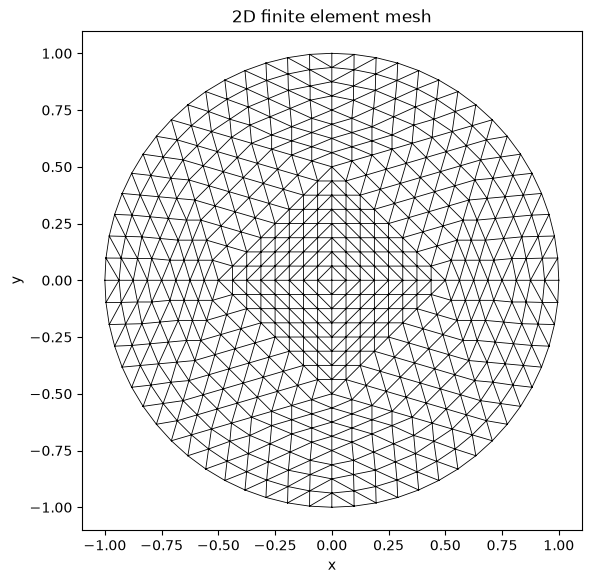

In [9]:
# Plot the Mesh in 2D
def plot_2d_mesh(mesh, figsize=(6, 6), show_node_ids=False):
    x = mesh.p[0, :]
    y = mesh.p[1, :]
    triangles = mesh.t.T

    triang = mtri.Triangulation(x, y, triangles)

    _, ax = plt.subplots(figsize=figsize)

    ax.triplot(triang, color='k', linewidth=0.6)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('2D finite element mesh')

    if show_node_ids:
        for i, (xi, yi) in enumerate(zip(x, y)):
            ax.text(xi, yi, str(i), fontsize=6, color='red')

    plt.tight_layout()
    plt.show()


plot_2d_mesh(MESH)

In [10]:
# Compute the matrices we need for building the SNN
GAMMA, W_SLOW, W_FAST, BIAS, THETA, V_RESET, TAU_A = build_neurofem_matrices(
    A,
    B,
    neurons_per_mesh_point=NEURONS_PER_MESH_POINT,
    gamma_norm=GAMMA_NORM,
)

print(f'GAMMA shape: {GAMMA.shape}')
print(f'W_SLOW shape: {W_SLOW.shape}')
print(f'W_FAST shape: {W_FAST.shape}')
print(f'BIAS shape: {BIAS.shape}')
print(f'THETA shape: {THETA.shape}')
print(f'V_RESET shape: {V_RESET.shape}')

GAMMA shape: (481, 3848)
W_SLOW shape: (3848, 3848)
W_FAST shape: (3848, 3848)
BIAS shape: (3848,)
THETA shape: (3848,)
V_RESET shape: (3848,)


# Sango Implementation

## Model Registry

In [11]:
FEM_MODEL_REGISTRY = {
    # Neurons
    'FEMNeuron': {
        'graph_type': 'neuron',
        'model_eqs': """
            du1/dt = -lambda_d * u1 / ms : 1
            du2/dt = -lambda_d * u2 / ms : 1
            du_int/dt = u_err / ms : 1
            u_err = u1 + bias : 1
            dv/dt = (-lambda_v * v + kp * u_err + ki * u_int + u2) / ms : 1
            bias : 1
            theta : 1
            v_reset : 1
            sigma_noise : 1
            lambda_d : 1
            lambda_v : 1
            kp : 1
            ki : 1
        """,
        'method': 'euler',
        'threshold': 'v > theta',
        'reset': 'v = v_reset',
        'events': {},
        'run_regularly': [
            {'eqs': 'v += sigma_noise * randn()', 'when': 'start'},
        ],
        'state': {
            'lambda_d': {'dsl': 'lambda_d', 'default': LAMBDA_D},
            'lambda_v': {'dsl': 'lambda_v', 'default': LAMBDA_V},
            'ki': {'dsl': 'ki', 'default': KI},
            'kp': {'dsl': 'kp', 'default': KP},
            'u1': {'dsl': 'u1', 'default': 0.0},
            'u2': {'dsl': 'u2', 'default': 0.0},
            'v': {'dsl': 'v', 'default': 0.0},
            'u_int': {'dsl': 'u_int', 'default': 0.0},
            'theta': {'dsl': 'theta', 'default': 0.0},
            'v_reset': {'dsl': 'v_reset', 'default': 0.0},
            'sigma_noise': {'dsl': 'sigma_noise', 'default': SIGMA_V},
            'bias': {'dsl': 'bias', 'default': 0.0},
        },
    },
    'FEMReadout': {
        'graph_type': 'neuron',
        'model_eqs': """
            dx/dt = -lambda_d * x / ms : 1
            lambda_d : 1
        """,
        'method': 'euler',
        'threshold': 'x > 1e100',
        'reset': 'x = x',
        'events': {},
        'run_regularly': [],
        'state': {
            'lambda_d': {'dsl': 'lambda_d', 'default': LAMBDA_D},
            'x': {'dsl': 'x', 'default': 0.0},
        },
    },
    # Synapses
    'FEMSlowFastSynapse': {
        'graph_type': 'synapse',
        'model_eqs': """
                slow_weight : 1
                fast_weight : 1
            """,
        'on_pre': """
                    u1_post += slow_weight
                    u2_post += 8.0 * fast_weight
                    v_post -= fast_weight
                """,
        'state': {
            'slow_weight': {'dsl': 'slow_weight', 'default': 0.0},
            'fast_weight': {'dsl': 'fast_weight', 'default': 0.0},
        },
    },
    'FEMReadoutSynapse': {
        'graph_type': 'synapse',
        'model_eqs': 'weight : 1',
        'on_pre': 'x_post += weight',
        'state': {
            'weight': {'dsl': 'weight', 'default': 1.0},
        },
    },
}

## Dataclasses for Mapping Parameters

### Neurons

In [12]:
@dataclass
class FEMNeuron(Neuron):
    model: str = 'FEMNeuron'
    lambda_d: float = LAMBDA_D
    lambda_v: float = LAMBDA_V
    kp: float = KP
    ki: float = KI
    u1: float = 0.0
    u2: float = 0.0
    v: float = 0.0
    # u_err: float = 0.0
    u_int: float = 0.0
    theta: float = 0.0
    v_reset: float = 0.0
    sigma_noise: float = SIGMA_V
    bias: float = 0.0


@dataclass
class FEMReadout(Neuron):
    model: str = 'FEMReadout'
    lambda_d: float = LAMBDA_D
    x: float = 0.0

### Synapses

In [13]:
@dataclass
class FEMReadoutSynapse(Synapse):
    model: str = 'FEMReadoutSynapse'
    weight: float = 0.0


@dataclass
class FEMSlowFastSynapse(Synapse):
    model: str = 'FEMSlowFastSynapse'
    slow_weight: float = 0.0
    fast_weight: float = 0.0

## Build the SNN

In [14]:
def dense_combined_to_edges(W: np.ndarray) -> tuple:
    """Convert dense combined matrix W[post, pre, channel] to edge list.

    Assumes:
        W[:, :, 0] = slow weights
        W[:, :, 1] = fast weights

    :param W: combined dense weight matrix containing slow and fast weights
    :type W: np.ndarray
    :return: (edges, slow_weights, fast_weights) where:
        - edges - list of tuples from source i to target j
        - slow_weights - list slow weights corresponding to the edges
        - fast_weights - list fast weights corresponding to the edges
    :rtype: tuple
    """

    W_slow_dense = W[:, :, 0]
    W_fast_dense = W[:, :, 1]

    # Mask where either channel is nonzero
    mask = (W_slow_dense != 0.0) | (W_fast_dense != 0.0)

    # post_idx, pre_idx because W is indexed as W[post, pre]
    post_idx, pre_idx = np.nonzero(mask)

    # Sango/Brian edges are source -> target, i.e. pre -> post
    edges = list(zip(pre_idx.astype(int), post_idx.astype(int)))

    slow_weights = W_slow_dense[post_idx, pre_idx]
    fast_weights = W_fast_dense[post_idx, pre_idx]

    return edges, slow_weights, fast_weights

### Construct the Sango Network

In [15]:
# Link G to network
NET = Network()

n_mesh = A.shape[0]
n_neurons = GAMMA.shape[1]

### Mesh Neurons and Connections

In [16]:
# Create one big group
NET.G = NodeGroup(
    model=FEMNeuron(),
    size=n_neurons,
    lambda_d=LAMBDA_D * np.ones(n_neurons),
    lambda_v=LAMBDA_V * np.ones(n_neurons),
    kp=KP * np.ones(n_neurons),
    ki=KI * np.ones(n_neurons),
    u1=np.zeros(n_neurons),
    u2=np.zeros(n_neurons),
    v=np.zeros(n_neurons),
    u_int=np.zeros(n_neurons),
    bias=BIAS,
    theta=THETA,
    v_reset=V_RESET,
    sigma_noise=SIGMA_V * np.ones(n_neurons),
)

W = np.stack([W_SLOW.toarray(), W_FAST.toarray()], axis=-1)
edges, slow_weights, fast_weights = dense_combined_to_edges(W)
NET.weights = EdgeGroup(
    NET.G,
    NET.G,
    model=FEMSlowFastSynapse(),
    edges=edges,
    slow_weight=slow_weights,
    fast_weight=fast_weights,
)

### Readout Neurons and Connections

In [17]:
# Readout
NET.R = NodeGroup(
    model=FEMReadout(),
    size=n_mesh,
    lambda_d=LAMBDA_D * np.ones(n_mesh),
    x=np.zeros(n_mesh),
)

gamma_i, gamma_j, gamma_w = sparse_matrix_to_brian_edges(GAMMA)
NET.readout_synapses = EdgeGroup(
    NET.G,
    NET.R,
    model=FEMReadoutSynapse(),
    edges=list(zip(gamma_i, gamma_j)),
    weight=gamma_w,
)

### Build the Sango Network

In [18]:
# Build the network in Sango
NET.build()

info: flattening network topology


# Brian 2 Simulation

In [19]:
# Brian2 Simulation
sim = SimBrian(NET, tstep=DT)
sim.model_registry.update(FEM_MODEL_REGISTRY)
sim.compile(debug=True)
# State Monitor
group = sim.neuron_groups['FEMReadout']
readout_state_monitor = StateMonitor(group, 'x', record=True)
sim.brian_net.add(readout_state_monitor)
# Run Brian2 Simulation
sim.run(SIMULATION_TIME)

Compile time: 1.1937117080087774


# Results & Comparisons

## Gather All Results

In [20]:
# Compute the error between the exact and the FEM solutions
X_FEM = spla.spsolve(A, B)

X_COORD = XY[:, 0]
Y_COORD = XY[:, 1]

X_EXACT = 5.0 * (1.0 - X_COORD**2 - Y_COORD**2)

# Extract SNN results
X_TRACE = np.asarray(readout_state_monitor.x)
X_SNN = np.mean(X_TRACE[:, -10000:], axis=1)

print(f'X_TRACE Shape: {X_TRACE.shape}')
print(f'X_SNN Shape: {X_SNN.shape}')
print(f'X_FEM Shape: {X_FEM.shape}')
print(f'X_EXACT Shape: {X_EXACT.shape}')

X_TRACE Shape: (481, 50000)
X_SNN Shape: (481,)
X_FEM Shape: (481,)
X_EXACT Shape: (481,)


## Compare Results

In [21]:
# Compare the FEM and exact solutions
rel_error = np.linalg.norm(X_FEM - X_EXACT) / np.linalg.norm(X_EXACT)
rel_resid_fem = np.linalg.norm(B - A @ X_FEM) / np.linalg.norm(B)

# Compare the SNN to the FEM and exact solutions
rel_err_snn_vs_fem = np.linalg.norm(X_SNN - X_FEM) / np.linalg.norm(X_FEM)
rel_err_snn_vs_exact = np.linalg.norm(X_SNN - X_EXACT) / np.linalg.norm(X_EXACT)
rel_resid_snn = np.linalg.norm(B - A @ X_SNN) / np.linalg.norm(B)

print(f'FEM vs analytic relative error: {rel_error:.3e}')
print(f'Linear-system relative residual: {rel_resid_fem:.3e}')
print(f'SNN vs FEM relative error:      {rel_err_snn_vs_fem:.6e}')
print(f'SNN vs analytic relative error: {rel_err_snn_vs_exact:.6e}')
print(f'SNN relative residual:          {rel_resid_snn:.6e}')

FEM vs analytic relative error: 1.057e-03
Linear-system relative residual: 1.408e-14
SNN vs FEM relative error:      1.339946e-04
SNN vs analytic relative error: 1.153303e-03
SNN relative residual:          1.679259e-03


## Plot the Solutions

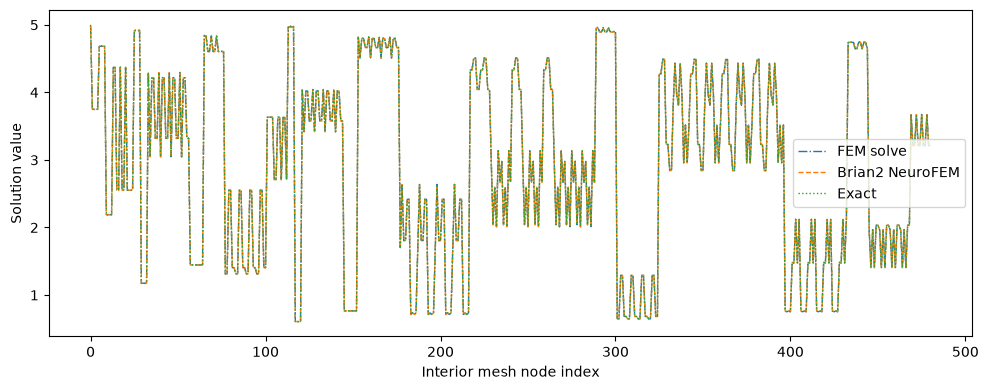

In [22]:
# Plot nodal values
plt.figure(figsize=(10, 4))
plt.plot(X_FEM, label='FEM solve', lw=1, linestyle='-.')
plt.plot(X_SNN, label='Brian2 NeuroFEM', lw=1, linestyle='--')
plt.plot(X_EXACT, label='Exact', lw=1, linestyle=':')
plt.xlabel('Interior mesh node index')
plt.ylabel('Solution value')
plt.legend()
plt.tight_layout()
plt.show()

# Visualization

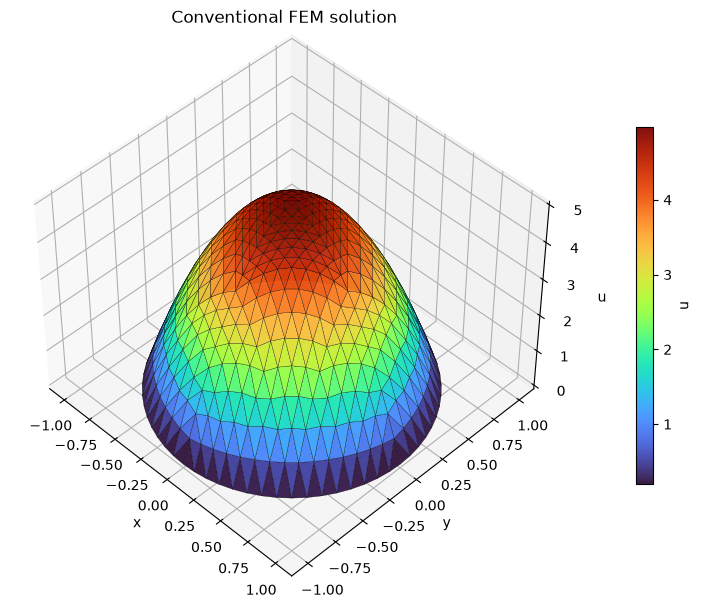

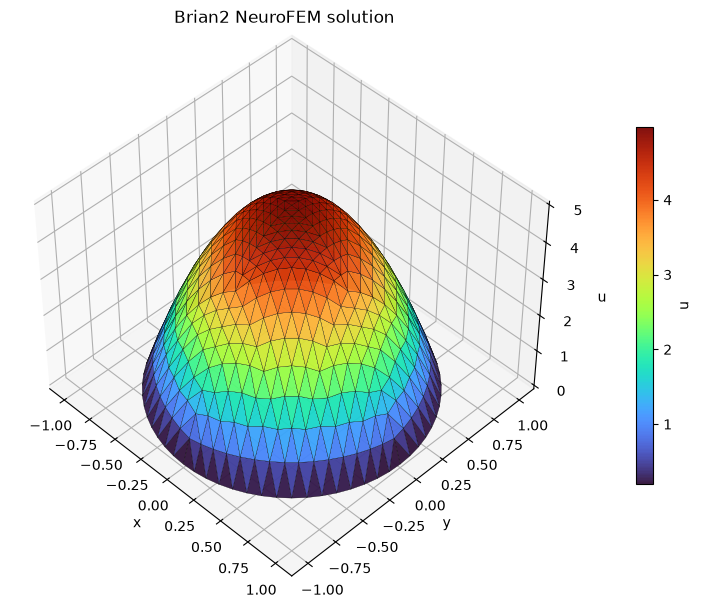

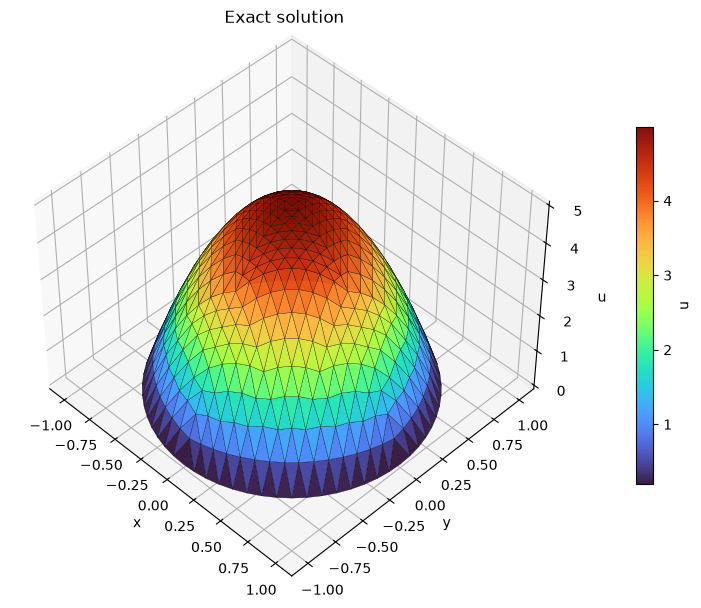

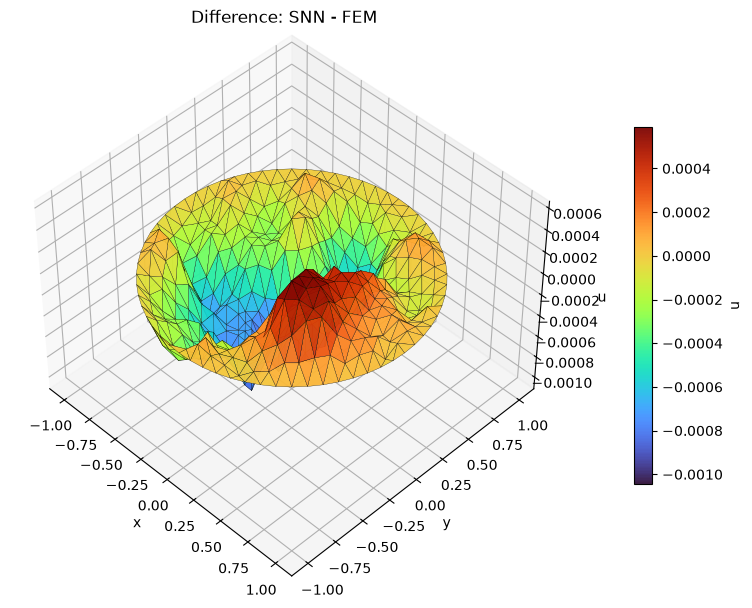

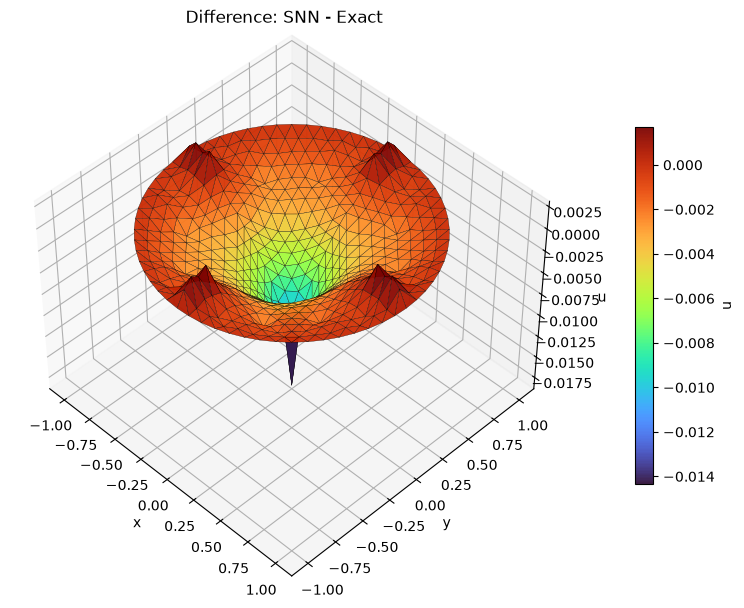

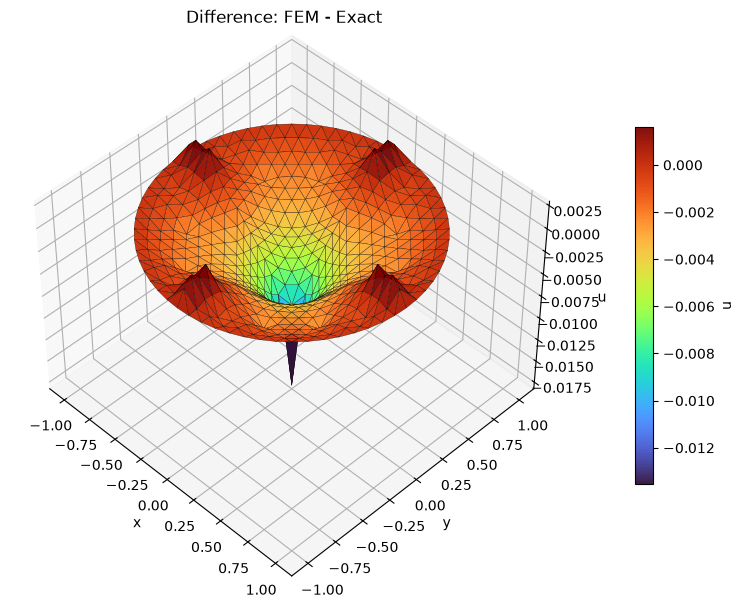

In [23]:
def plot_disk_solution_3d(
    mesh: MeshTri,
    interior: np.ndarray,
    values: np.ndarray,
    title: str = 'solution',
    cmap: str = 'turbo',
    elev: int = 45,
    azim: int = -45,
) -> None:
    """
    Plot an interior-only FEM/SNN solution on the disk as a 3D surface.

    :param mesh: full triangular mesh of the disk
    :type mesh: MeshTri
    :param interior: indices of the interior mesh nodes
    :type interior: np.ndarray
    :param values: solution values at the interior mesh nodes
    :type values: np.ndarray
    :param title: title displayed above the plot, defaults to 'solution'
    :type title: str, optional
    :param cmap: colormap used for the surface, defaults to 'turbo'
    :type cmap: str, optional
    :param elev: elevation angle, in degrees, for the 3D view, defaults to 45
    :type elev: int, optional
    :param azim: azimuth angle, in degrees, for the 3D view, defaults to -45
    :type azim: int, optional
    :returns: None. Displays a Matplotlib 3D triangular surface plot.
    :rtype: None
    """

    n_vertices = mesh.p.shape[1]

    # Insert zero Dirichlet boundary values
    full_values = np.zeros(n_vertices)
    full_values[interior] = values

    x = mesh.p[0, :]
    y = mesh.p[1, :]
    z = full_values

    triang = mtri.Triangulation(
        x,
        y,
        mesh.t.T,
    )

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_trisurf(
        triang,
        z,
        cmap=cmap,
        linewidth=0.2,
        edgecolor='k',
        alpha=0.95,
        antialiased=True,
    )

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')

    ax.view_init(elev=elev, azim=azim)

    fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1, label='u')
    plt.tight_layout()
    plt.show()


plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_FEM,
    title='Conventional FEM solution',
    cmap='turbo',
)

plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_SNN,
    title='Brian2 NeuroFEM solution',
    cmap='turbo',
)

plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_EXACT,
    title='Exact solution',
    cmap='turbo',
)

plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_SNN - X_FEM,
    title='Difference: SNN - FEM',
    cmap='turbo',
)

plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_SNN - X_EXACT,
    title='Difference: SNN - Exact',
    cmap='turbo',
)

plot_disk_solution_3d(
    MESH,
    INTERIOR,
    X_FEM - X_EXACT,
    title='Difference: FEM - Exact',
    cmap='turbo',
)